In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1 as ff1
import os

In [3]:
def get_session(year, event, session_type,check_cache=True):
    """
    Get a FastF1 session.

    Parameters:
    year (int): The year of the session.
    event (str): The event name (e.g., 'Monza').
    session_type (str): The session type (e.g., 'R' for race).
    """
    if check_cache:
        os.makedirs('fastf1_cache', exist_ok=True)
        ff1.Cache.enable_cache('fastf1_cache')
    session = ff1.get_session(year, event, session_type)
    return session



In [19]:

def combine_telemetry_with_laps(laps,session_type):
    """
    Combine telemetry data with lap data.

    Parameters:
    laps (pd.DataFrame): The laps DataFrame containing lap information.
    session_type (str): The type of the session (e.g., 'R' for race, 'Q' for qualifying).

    Returns:
    pd.DataFrame: A DataFrame containing combined telemetry and lap data.
    """
    if session_type not in ['R', 'Q']:
        raise ValueError("session_type must be 'R' (race) or 'Q' (qualifying).")

    if session_type == 'R':
        laps_cleaned = laps.loc[(laps['IsAccurate'] == True) &
                         (laps['LapTime'].notna()) &
                         (laps['PitOutTime'].isna()) &
                         (laps['PitInTime'].isna()) &
                         (laps['TrackStatus'] == '1')].copy()
    else:
        laps_cleaned = laps.loc[(laps['LapTime'].notna())]

    laps_cleaned['LapTimeSeconds'] = laps_cleaned['LapTime'].dt.total_seconds()
    laps = laps_cleaned
    lap_cols = ['Driver', 'DriverNumber', 'Team', 'LapNumber', 'Stint', 'Compound',
                'TyreLife', 'FreshTyre', 'LapTimeSeconds', 'Position',
                'LapStartTime', 'Time']

    combined_frames = []
    for driver in laps['Driver'].unique():
        driver_laps = laps[laps['Driver'] == driver].sort_values('LapStartTime')

        tel = driver_laps.get_car_data()
        if tel.empty:
            continue
        tel = tel.sort_values('SessionTime').rename(columns={'Time': 'TelTime'})

        laps_meta = driver_laps[lap_cols].rename(columns={'Time': 'LapEndTime'})

        merged = pd.merge_asof(
            tel, laps_meta,
            left_on='SessionTime', right_on='LapStartTime',
            direction='backward',
        )

        # keep only samples that actually fall inside a clean lap (drop gaps:
        # pit / SC / non-green laps that were filtered out of clean_laps)
        merged = merged[merged['SessionTime'].between(merged['LapStartTime'],
                                                    merged['LapEndTime'])]
        combined_frames.append(merged)

    telemetry_with_laps = pd.concat(combined_frames, ignore_index=True)
    return telemetry_with_laps
    

In [36]:
session = get_session(2026, 'Monza', 'q')
session.load()
laps = session.laps
telemetry_with_laps = combine_telemetry_with_laps(laps, session_type='Q')
telemetry_with_laps.info()

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['10', '63', '81', '16', '44', '3', '12', '43', '1', '41', '5', '87', '27', '30', '55', '31', '22', '23', '77', '11', '14', '18']


<class 'fastf1.core.Telemetry'>
RangeIndex: 71614 entries, 0 to 71613
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   Date            71614 non-null  datetime64[ns] 
 1   RPM             71614 non-null  float64        
 2   Speed           71614 non-null  float64        
 3   nGear           71614 non-null  int64          
 4   Throttle        71614 non-null  float64        
 5   Brake           71614 non-null  bool           
 6   DRS             71614 non-null  int64          
 7   Source          71614 non-null  object         
 8   TelTime         71614 non-null  timedelta64[ns]
 9   SessionTime     71614 non-null  timedelta64[ns]
 10  Driver          71614 non-null  object         
 11  DriverNumber    71614 non-null  object         
 12  Team            71614 non-null  object         
 13  LapNumber       71614 non-null  float64        
 14  Stint           71614 non-null  float64     

C:\Users\karan\AppData\Local\Temp\ipykernel_28928\1175327155.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laps_cleaned['LapTimeSeconds'] = laps_cleaned['LapTime'].dt.total_seconds()


In [37]:
# flying laps only: sample must belong to a lap that set a time, and that lap
# must be within 107% of the session's best (drops aborted / backed-off laps)
timed = telemetry_with_laps['LapTimeSeconds'].notna()
best = telemetry_with_laps.loc[timed, 'LapTimeSeconds'].min()
flying = telemetry_with_laps[timed & (telemetry_with_laps['LapTimeSeconds'] <= 1.07 * best)]

telemetry_grp_teams = (flying.groupby('Team')
                       .agg(MeanLapTimeSeconds=('LapTimeSeconds', 'mean'),
                            MeanSpeed=('Speed', 'mean'),
                            MaxSpeed=('Speed', 'max'))
                       .reset_index())
telemetry_grp_teams

,Team,MeanLapTimeSeconds,MeanSpeed,MaxSpeed
0,Alpine,82.373512,257.018423,342.0
1,Aston Martin,85.612867,243.002509,324.0
2,Audi,83.086495,249.149254,337.0
3,Cadillac,84.981920,245.914422,339.0
4,Ferrari,82.563610,251.058373,338.0
5,Haas F1 Team,83.540005,248.518914,341.0
6,McLaren,82.454326,250.699556,337.0
7,Mercedes,82.294053,252.431965,345.0
8,Racing Bulls,82.898389,249.566265,333.0
9,Red Bull Racing,82.826639,250.387435,335.0


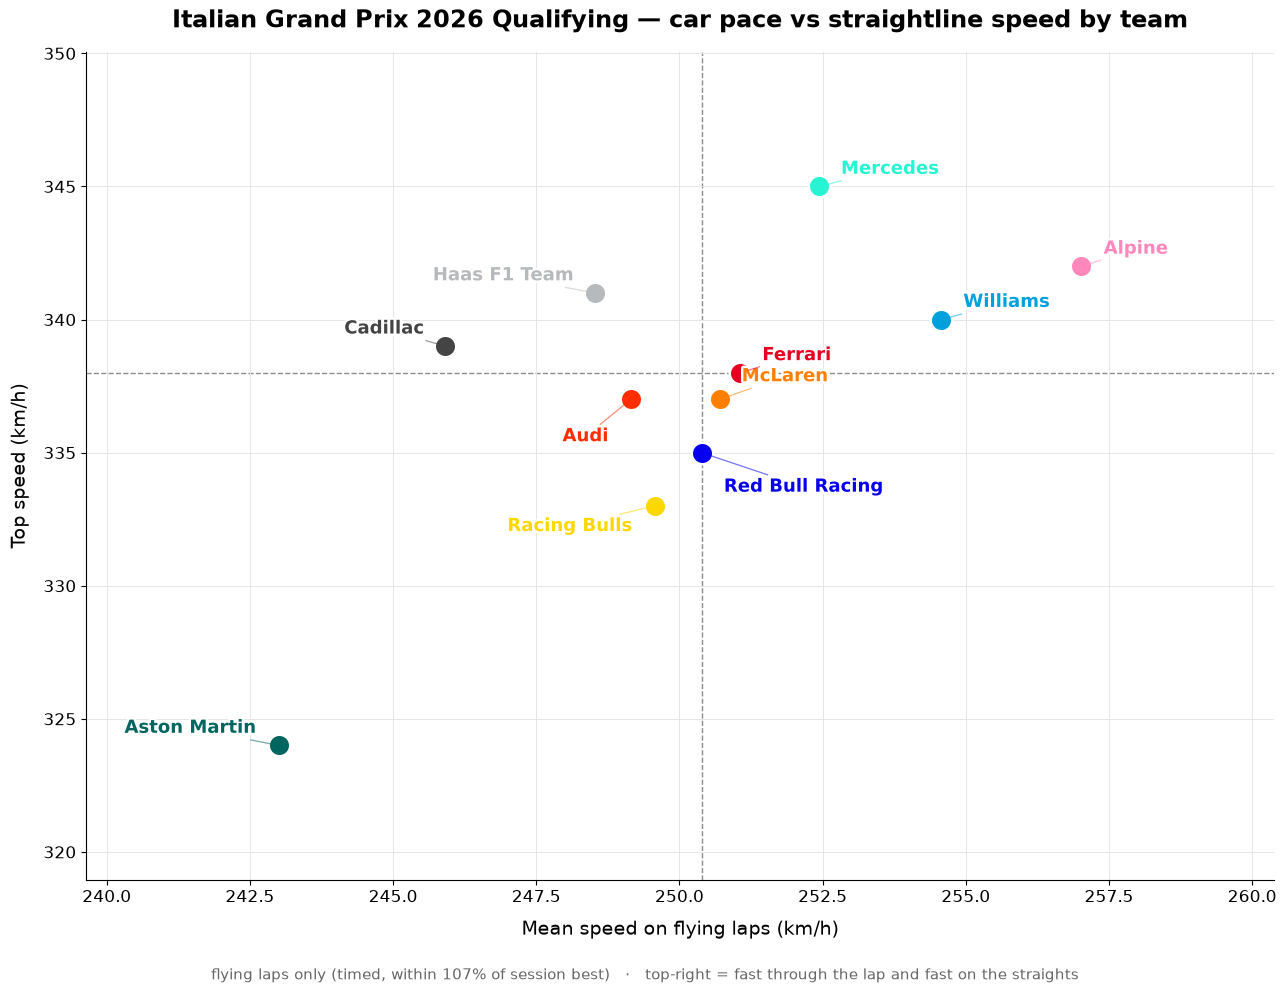

In [38]:
import fastf1.plotting as f1plt
import matplotlib.patheffects as pe

f1plt.setup_mpl()

d = telemetry_grp_teams.sort_values('MeanSpeed').reset_index(drop=True)
x_mid, y_mid = d['MeanSpeed'].median(), d['MaxSpeed'].median()

# nudge labels away from both medians so nearby points never share label space;
# per-team overrides for the few unavoidable collisions
offset = {'right': (16, 6), 'left': (-16, 6)}
override = {
    'Audi':    (-16, -20),   # sits just left of McLaren
    'McLaren': (16, 10),
    'Red Bull Racing': (16, -18),
    'Racing Bulls':    (-16, -8),
}

fig, ax = plt.subplots(figsize=(13, 10))
ax.axvline(x_mid, color='0.55', lw=1, ls='--', zorder=1)
ax.axhline(y_mid, color='0.55', lw=1, ls='--', zorder=1)
ax.grid(True, color='0.9', lw=0.7, zorder=0)

halo = [pe.withStroke(linewidth=3.5, foreground='white')]
for _, row in d.iterrows():
    team, x, y = row['Team'], row['MeanSpeed'], row['MaxSpeed']
    try:
        color = f1plt.get_team_color(team, session=session)
    except Exception:
        color = 'C0'
    ax.scatter(x, y, s=240, color=color, edgecolor='white', linewidth=1.8, zorder=3)

    dx, dy = override.get(team, offset['right' if x >= x_mid else 'left'])
    ax.annotate(team, (x, y), xytext=(dx, dy), textcoords='offset points',
                ha='left' if dx > 0 else 'right',
                va='bottom' if dy >= 0 else 'top',
                fontsize=13, fontweight='bold', color=color,
                path_effects=halo, zorder=4,
                arrowprops=dict(arrowstyle='-', color=color, lw=0.9,
                                shrinkA=0, shrinkB=6, alpha=0.55))

ax.set_xlabel('Mean speed on flying laps (km/h)', fontsize=14, labelpad=10)
ax.set_ylabel('Top speed (km/h)', fontsize=14, labelpad=10)
ax.set_title(f"{session.event['EventName']} {session.event.year} Qualifying — car pace vs straightline speed by team",
             fontsize=17, fontweight='bold', pad=18)
ax.tick_params(labelsize=12)
ax.margins(0.24)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

fig.text(0.5, 0.015,
         'flying laps only (timed, within 107% of session best)   ·   '
         'top-right = fast through the lap and fast on the straights',
         ha='center', fontsize=11, color='0.4')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

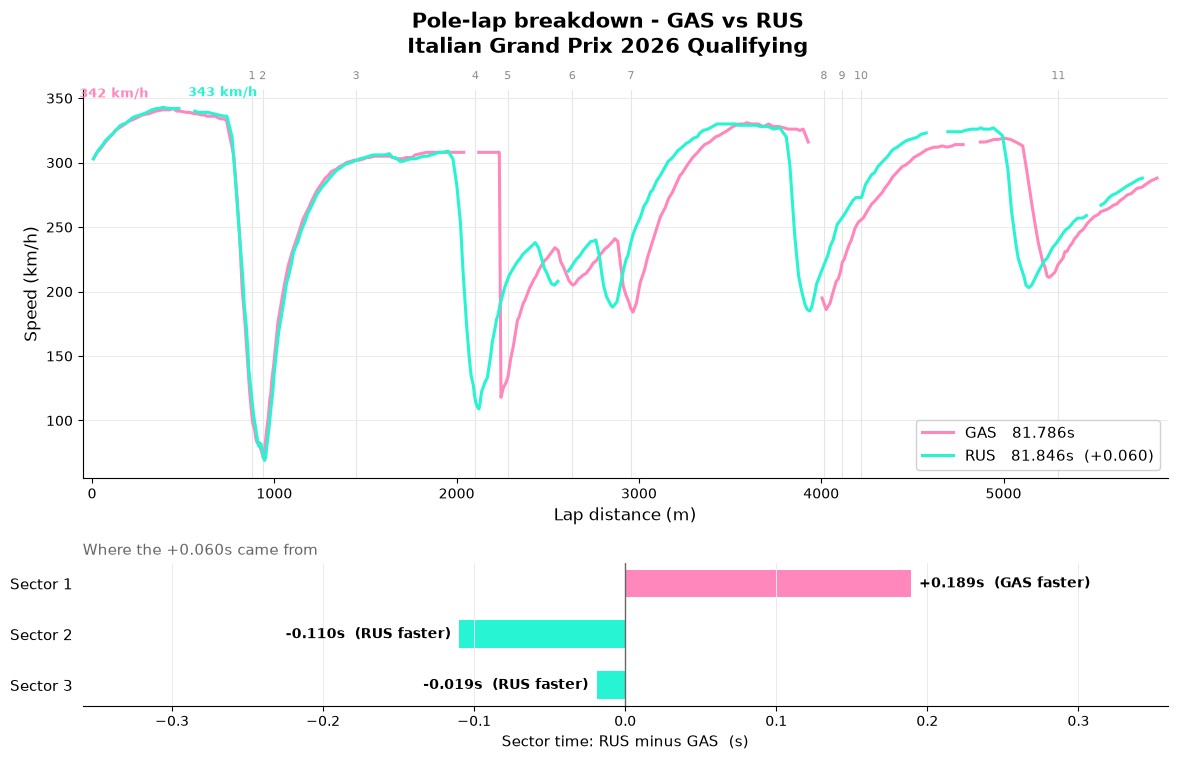

In [39]:
import fastf1.plotting as f1plt

f1plt.setup_mpl()

# two quickest drivers in the session, by best lap
order = session.laps.groupby('Driver')['LapTime'].min().sort_values()
d1, d2 = order.index[:2]
lap1 = session.laps.pick_drivers(d1).pick_fastest()
lap2 = session.laps.pick_drivers(d2).pick_fastest()

def team_color(lap, fallback):
    try:
        return f1plt.get_team_color(lap['Team'], session=session)
    except Exception:
        return fallback
c1 = team_color(lap1, '#e10600')
c2 = team_color(lap2, '#00a0dd')
ls2 = '--' if c1 == c2 else '-'

# speed vs distance; break the line across telemetry sampling gaps (>0.5 s)
# instead of drawing a misleading straight segment through them
def speed_trace(lap):
    car = lap.get_car_data().add_distance()
    t = car['Time'].dt.total_seconds().to_numpy()
    d = car['Distance'].to_numpy()
    v = car['Speed'].astype(float).to_numpy()
    v[np.concatenate([[False], np.diff(t) > 0.5])] = np.nan
    return d, v
d1x, v1x = speed_trace(lap1)
d2x, v2x = speed_trace(lap2)

# sector deltas from official timing (clean; telemetry gaps don't touch this)
g = np.array([lap1[f'Sector{i}Time'].total_seconds() for i in (1, 2, 3)])
r = np.array([lap2[f'Sector{i}Time'].total_seconds() for i in (1, 2, 3)])
sec_delta = r - g                         # +ve => d1 faster in that sector

fig, (ax, axs) = plt.subplots(
    2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1.1]})
fig.subplots_adjust(hspace=0.32)

# --- speed trace -----------------------------------------------------------
try:
    for _, cn in session.get_circuit_info().corners.iterrows():
        ax.axvline(cn['Distance'], color='0.9', lw=0.8, zorder=0)
        ax.text(cn['Distance'], 1.02, f"{cn['Number']}{cn['Letter']}",
                transform=ax.get_xaxis_transform(), ha='center', va='bottom',
                fontsize=8, color='0.55')
except Exception:
    pass

t1, t2 = lap1['LapTime'].total_seconds(), lap2['LapTime'].total_seconds()
ax.plot(d1x, v1x, color=c1, lw=2.2, label=f"{d1}   {t1:.3f}s")
ax.plot(d2x, v2x, color=c2, lw=2.2, ls=ls2,
        label=f"{d2}   {t2:.3f}s  (+{t2 - t1:.3f})")
for d, v, c, off in ((d1x, v1x, c1, (-18, 8)), (d2x, v2x, c2, (18, 8))):
    i = int(np.nanargmax(v))
    ax.annotate(f"{v[i]:.0f} km/h", (d[i], v[i]), textcoords='offset points',
                xytext=off, ha='right' if off[0] < 0 else 'left',
                fontsize=9, fontweight='bold', color=c)
ax.set_xlabel('Lap distance (m)', fontsize=12)
ax.set_ylabel('Speed (km/h)', fontsize=12)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(True, axis='y', color='0.92', lw=0.7)
ax.margins(x=0.01)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

# --- sector delta bar ----------------------------------------------------
ypos = np.arange(3)[::-1]
bar_colors = [c1 if v > 0 else c2 for v in sec_delta]
axs.barh(ypos, sec_delta, color=bar_colors, height=0.55)
axs.axvline(0, color='0.4', lw=1)
axs.set_yticks(ypos, ['Sector 1', 'Sector 2', 'Sector 3'], fontsize=11)
for y, v in zip(ypos, sec_delta):
    axs.annotate(f"{v:+.3f}s  ({d1 if v > 0 else d2} faster)",
                 (v, y), xytext=(6 if v > 0 else -6, 0),
                 textcoords='offset points', va='center',
                 ha='left' if v > 0 else 'right', fontsize=10, fontweight='bold')
lim = np.abs(sec_delta).max() * 1.9
axs.set_xlim(-lim, lim)
axs.set_xlabel(f'Sector time: {d2} minus {d1}  (s)', fontsize=11)
axs.set_title(f'Where the {t2 - t1:+.3f}s came from', fontsize=11, loc='left', color='0.4')
axs.grid(True, axis='x', color='0.92', lw=0.7)
for sp in ('top', 'right', 'left'):
    axs.spines[sp].set_visible(False)
axs.tick_params(left=False)

fig.suptitle(
    f"Pole-lap breakdown - {d1} vs {d2}\n"
    f"{session.event['EventName']} {session.event.year} Qualifying",
    fontsize=15, fontweight='bold')
plt.show()